
# 25 — First-order logic and HLLSet Algebra, on real HLLSets

Validates [`docs/FOL_HLLSET.md`](../docs/FOL_HLLSET.md) numerically, with the
bit-exact Python mirror of the soldered morphism (`P=10`, `M=1024`,
`BITS_PER_REG=32`, `TOTAL_BITS=32768`) used by notebooks 22–24.

What is checked, section by section:

| § | claim | how |
| - | - | - |
| 3 | HLLSet algebra **is** a Boolean algebra, hence propositional logic | Boolean laws, canonical form by content id, `⊨` as `⊆` |
| 5 | monadic `∃`/`∀` over a coordinate = fibre projection | closure/idempotence/De Morgan/Galois laws, commutation, join-classes, two-valuedness iff the coordinates separate `U` |
| 4 | local universes and transport | `[∅,L]` is Boolean, restriction `X ↦ X∩L'` is a homomorphism, retract, gluing, world-relative validity |
| 3.4 | forgetfulness is the kernel | a real collision: `μ(A∩B) ≠ μ(A)∩μ(B)`, multiplicity invisible |
| 3.5 | triangulation = meet of partitions | n-seed candidate decay vs `m^{-k}`, fibre-intersection materialization, n-gram refinement |


## §0 — The mirror: morphism, content id, fibres

A token lands on one bit address; an HLLSet is a bit vector; the content id is
the SHA-1 of those bits (the notebook stand-in for `h:<sha1>`). Fibres are the
level sets of a plane coordinate, so `∃`/`∀` are plain bit operations.

In [1]:

import collections
import hashlib
import pathlib
import random

import mmh3
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt


def find_root(start):
    for anc in [start, *list(start.parents)[:4]]:
        for cand in [anc, *[p for p in anc.iterdir() if p.is_dir()]]:
            if (cand / "crates" / "hllset-contracts").exists():
                return cand
    return None


ROOT = find_root(pathlib.Path.cwd())
assert ROOT is not None, "run this notebook from the repo or its notebooks/ directory"

P, M, BITS_PER_REG = 10, 1024, 32
PLANE_BITS = M * BITS_PER_REG
PLANE_BYTES = PLANE_BITS // 8
assert (P, M, BITS_PER_REG, PLANE_BITS) == (10, 1024, 32, 32768)
assert mmh3.hash64(b"tid0", seed=0, signed=False)[0] == 2_892_634_914_804_110_692

CHECKS = []


def law(name, ok):
    ok = bool(ok)
    CHECKS.append((name, ok))
    print("  %-52s %s" % (name, "ok" if ok else "FAIL"))
    return ok


def site(tok, seed=0):
    """BitAddress::of_token_seeded — the soldered insertion rule."""
    h = mmh3.hash64(tok.encode(), seed=seed, signed=False)[0]
    reg = h & (M - 1)
    rem = h >> P
    tz = 31 if rem == 0 else min((rem & -rem).bit_length() - 1, 31)
    return reg * BITS_PER_REG + tz


def hllset(tokens, seed=0):
    m = 0
    for t in tokens:
        m |= 1 << site(t, seed)
    return m


popcount = int.bit_count
union = lambda a, b: a | b
inter = lambda a, b: a & b
difference = lambda a, b: a & ~b
symdiff = lambda a, b: a ^ b


def neg(x, U):
    """Local negation: complement inside the universe U, never the raw plane."""
    return U & ~x


def cid(x):
    return "h:" + hashlib.sha1(x.to_bytes(PLANE_BYTES, "big")).hexdigest()[:12]


def bits_of(x):
    while x:
        b = x & -x
        yield b.bit_length() - 1
        x ^= b


def sample_of(x, p=0.5, rng=random):
    return sum(1 << b for b in bits_of(x) if rng.random() < p)


def _tz(p):
    return p % BITS_PER_REG


def _reg(p):
    return p // BITS_PER_REG


COORD = {"tz": _tz, "reg": _reg}
FIBRE = {
    "tz": [sum(1 << p for p in range(i, PLANE_BITS, BITS_PER_REG))
           for i in range(BITS_PER_REG)],
    "reg": [((1 << BITS_PER_REG) - 1) << (BITS_PER_REG * j) for j in range(M)],
}


def exists_c(x, coord, U):
    """exists over a coordinate: union of the fibres of U that the set meets."""
    out = 0
    for p in bits_of(x & U):
        out |= FIBRE[coord][COORD[coord](p)] & U
    return out


def forall_c(x, coord, U):
    """forall over a coordinate: union of the fibres of U contained in the set."""
    out = 0
    for mask in FIBRE[coord]:
        f = mask & U
        if f and (f & ~x) == 0:
            out |= f
    return out


print("mirror ready | plane = %d bits | coordinates = %s" % (PLANE_BITS, sorted(COORD)))

mirror ready | plane = 32768 bits | coordinates = ['reg', 'tz']



## §1 — HLLSet algebra is a Boolean algebra, hence propositional logic

Atoms are HLLSets; `∧ = ∩`, `∨ = ∪`, `¬ = U \ ·` with `U = ⋃ atoms` (the local
universe). Truth is relative to `U`, validity is `⟦φ⟧ = U`, consequence is
`⟦φ⟧ ⊆ ⟦ψ⟧`, and equivalence is a content-id comparison — so the *bitmap is the
normal form*.

In [2]:

A = hllset([f"t{i}" for i in range(0, 60)])
B = hllset([f"t{i}" for i in range(40, 100)])
C = hllset([f"t{i}" for i in range(80, 120)])
U = A | B | C
print("atoms: |A|=%d |B|=%d |C|=%d bits | universe |U|=%d bits"
      % (popcount(A), popcount(B), popcount(C), popcount(U)))

law("involutive negation   not not phi = phi", neg(neg(A, U), U) == A)
law("idempotence           phi and phi = phi", inter(A, A) == A)
law("excluded middle       phi or not phi = U", union(A, neg(A, U)) == U)
law("contradiction         phi and not phi = empty", inter(A, neg(A, U)) == 0)
law("De Morgan             not(phi or psi) = not phi and not psi",
    neg(union(A, B), U) == inter(neg(A, U), neg(B, U)))
law("distributivity        phi and (psi or chi) = (phi and psi) or (phi and chi)",
    inter(A, union(B, C)) == union(inter(A, B), inter(A, C)))

lhs = union(inter(A, B), inter(A, C))
rhs = inter(A, union(B, C))
print("  (A and B) or (A and C): %s  (%d bits)" % (cid(lhs), popcount(lhs)))
print("  A and (B or C)        : %s  (%d bits)" % (cid(rhs), popcount(rhs)))
law("canonical form: equal truth sets share one content id", lhs == rhs and cid(lhs) == cid(rhs))

law("consequence  phi |= psi iff [[phi]] subset [[psi]]   (A and B |= A)",
    (inter(A, B) & ~A) == 0)
imp = union(neg(A, U), B)
law("modus ponens A and (A -> B) |= B", (inter(A, imp) & ~B) == 0)
law("validity [[phi]]=U, unsatisfiable [[phi]]=empty",
    union(A, neg(A, U)) == U and inter(A, neg(A, U)) == 0)

atoms: |A|=60 |B|=59 |C|=39 bits | universe |U|=118 bits
  involutive negation   not not phi = phi              ok
  idempotence           phi and phi = phi              ok
  excluded middle       phi or not phi = U             ok
  contradiction         phi and not phi = empty        ok
  De Morgan             not(phi or psi) = not phi and not psi ok
  distributivity        phi and (psi or chi) = (phi and psi) or (phi and chi) ok
  (A and B) or (A and C): h:8b04879ce8f2  (20 bits)
  A and (B or C)        : h:8b04879ce8f2  (20 bits)
  canonical form: equal truth sets share one content id ok
  consequence  phi |= psi iff [[phi]] subset [[psi]]   (A and B |= A) ok
  modus ponens A and (A -> B) |= B                     ok
  validity [[phi]]=U, unsatisfiable [[phi]]=empty      ok


True


## §2 — Monadic quantification: `∃`/`∀` over one coordinate

`∃_c` saturates along the fibres of the coordinate; `∀_c` is its dual. Over the
soldered plane the coordinates are `tz` (32 values) and `reg` (1024). The laws
are bitmap identities, so each is decidable; quantifying *every* coordinate
leaves `∅` or `U` (quantifier elimination).

In [3]:

random.seed(0)
X = sample_of(U, 0.30)
Y = sample_of(U, 0.30)
print("X, Y random subsets of U: |X|=%d |Y|=%d bits" % (popcount(X), popcount(Y)))

law("extensive    X subset existsX", (X & ~exists_c(X, "tz", U)) == 0)
law("idempotent   exists exists X = exists X",
    exists_c(exists_c(X, "tz", U), "tz", U) == exists_c(X, "tz", U))
law("contractive  forallX subset X", (forall_c(X, "tz", U) & ~X) == 0)
law("idempotent   forall forall X = forall X",
    forall_c(forall_c(X, "tz", U), "tz", U) == forall_c(X, "tz", U))
law("exists(X or Y) = existsX or existsY",
    exists_c(union(X, Y), "tz", U) == union(exists_c(X, "tz", U), exists_c(Y, "tz", U)))
law("forall(X and Y) = forallX and forallY",
    forall_c(inter(X, Y), "tz", U) == inter(forall_c(X, "tz", U), forall_c(Y, "tz", U)))
law("De Morgan   not existsX = forall not X",
    neg(exists_c(X, "tz", U), U) == forall_c(neg(X, U), "tz", U))
law("De Morgan   not forallX = exists not X",
    neg(forall_c(X, "tz", U), U) == exists_c(neg(X, U), "tz", U))

S = exists_c(sample_of(U, 0.30), "tz", U)          # a saturated set
law("Galois: existsX subset S  iff  X subset S   (S saturated)",
    ((exists_c(X, "tz", U) & ~S) == 0) == ((X & ~S) == 0))

Z = inter(X, Y)
law("monotone: Z subset X implies existsZ subset existsX",
    (exists_c(Z, "tz", U) & ~exists_c(X, "tz", U)) == 0)

law("quantifiers commute   exists_tz exists_reg = exists_reg exists_tz",
    exists_c(exists_c(X, "tz", U), "reg", U) == exists_c(exists_c(X, "reg", U), "tz", U))

QX = exists_c(X, "tz", U)
law("after exists tz the result is tz-saturated", exists_c(QX, "tz", U) == QX)


def join_classes(L):
    """Classes of `share a reg or a tz`: components of the reg-tz bipartite graph."""
    parent = {}

    def find(x):
        parent.setdefault(x, x)
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    for p in bits_of(L):
        r, t = ("R", p // BITS_PER_REG), ("T", p % BITS_PER_REG)
        ra, rb = find(r), find(t)
        if ra != rb:
            parent[ra] = rb
    return {p: find(("R", p // BITS_PER_REG)) for p in bits_of(L)}


lab = join_classes(U)
classes = set(lab.values())
sentence = exists_c(exists_c(X, "reg", U), "tz", U)
print("  local universe U: %d sites -> %d join-class(es)" % (popcount(U), len(classes)))
law("sentence is a union of join-classes",
    all(len({(sentence >> p) & 1 for p, cc in lab.items() if cc == c}) == 1 for c in classes))
law("not two-valued: the sentence is neither empty nor U", sentence != 0 and sentence != U)

FULL = (1 << PLANE_BITS) - 1
full_lab = join_classes(FULL)
law("the full plane is separated: exactly one join-class", len(set(full_lab.values())) == 1)
law("separated universe: sentences collapse to empty or U",
    exists_c(exists_c(X, "tz", FULL), "reg", FULL) in (0, FULL))
print("  sentence = %d of %d bits (empty=%s, U=%s) | on the full plane -> U=%s"
      % (popcount(sentence), popcount(U), sentence == 0, sentence == U,
         exists_c(exists_c(X, "tz", FULL), "reg", FULL) == FULL))

def toy_exists(X):
    F = [frozenset(p for p in range(8) if p % 4 == i) for i in range(4)]
    return set().union(*[f for f in F if X & f]) if X else set()


def toy_forall(X):
    F = [frozenset(p for p in range(8) if p % 4 == i) for i in range(4)]
    return set().union(*[f for f in F if f <= X]) if X else set()


X0 = {0, 5}
print("  toy plane |P|=8, c(p)=p mod 4:  X=%s  existsX=%s  forallX=%s"
      % (sorted(X0), sorted(toy_exists(X0)), sorted(toy_forall(X0))))
law("toy example matches the doc ({0,1,4,5}, empty)",
    toy_exists(X0) == {0, 1, 4, 5} and toy_forall(X0) == set())

X, Y random subsets of U: |X|=25 |Y|=37 bits
  extensive    X subset existsX                        ok
  idempotent   exists exists X = exists X              ok
  contractive  forallX subset X                        ok
  idempotent   forall forall X = forall X              ok
  exists(X or Y) = existsX or existsY                  ok
  forall(X and Y) = forallX and forallY                ok
  De Morgan   not existsX = forall not X               ok
  De Morgan   not forallX = exists not X               ok
  Galois: existsX subset S  iff  X subset S   (S saturated) ok
  monotone: Z subset X implies existsZ subset existsX  ok
  quantifiers commute   exists_tz exists_reg = exists_reg exists_tz ok
  after exists tz the result is tz-saturated           ok
  local universe U: 118 sites -> 4 join-class(es)
  sentence is a union of join-classes                  ok
  not two-valued: the sentence is neither empty nor U  ok
  the full plane is separated: exactly one join-class  ok
  separated unive

True


## §3 — Local universes and transport

Each universe `L` gives the Boolean algebra `[∅, L]` with local negation
`L \ ·`. For `L' ⊆ L`, restriction `X ↦ X ∩ L'` is a **Boolean homomorphism**,
`B_{L'}` is a retract of `B_L`, compatible local truths **glue**, and the same
formula can be valid in one universe and not another.

In [4]:

L1, L2 = union(A, B), union(B, C)
L = union(L1, L2)
Lp = inter(L1, L2)
print("universes: |L1|=%d |L2|=%d |L1 and L2|=%d |L1 or L2|=%d bits"
      % (popcount(L1), popcount(L2), popcount(Lp), popcount(L)))

X = sample_of(L, 0.30)
Y = sample_of(L, 0.30)
rho = lambda x: x & Lp
law("restriction preserves or", rho(union(X, Y)) == union(rho(X), rho(Y)))
law("restriction preserves and", rho(inter(X, Y)) == inter(rho(X), rho(Y)))
law("restriction preserves local negation", rho(neg(X, L)) == neg(rho(X), Lp))
law("restriction preserves empty and L", rho(0) == 0 and rho(L) == Lp)
Z = sample_of(Lp, 0.5)
law("retract: rho(iota(Z)) = Z", rho(Z) == Z)

X1 = sample_of(L1, 0.30)
X2 = (sample_of(L2, 0.30) & ~Lp) | (X1 & Lp)          # force compatibility on the overlap
glued = union(X1, X2)
law("gluing: (X1 or X2) and L1 = X1,  and L2 = X2",
    inter(glued, L1) == X1 and inter(glued, L2) == X2)

phi = L1
print("  [[phi]] = L1: valid in L1 = %s | valid in L2 = %s"
      % (inter(phi, L1) == L1, inter(phi, L2) == L2))
print("  BSS(phi, L1) = %.2f | BSS(phi, L2) = %.2f"
      % (popcount(inter(phi, L1)) / popcount(L1), popcount(inter(phi, L2)) / popcount(L2)))
law("world-relative logic: valid in one universe, not the other",
    (inter(phi, L1) == L1) and (inter(phi, L2) != L2))

universes: |L1|=99 |L2|=78 |L1 and L2|=59 |L1 or L2|=118 bits
  restriction preserves or                             ok
  restriction preserves and                            ok
  restriction preserves local negation                 ok
  restriction preserves empty and L                    ok
  retract: rho(iota(Z)) = Z                            ok
  gluing: (X1 or X2) and L1 = X1,  and L2 = X2         ok
  [[phi]] = L1: valid in L1 = True | valid in L2 = False
  BSS(phi, L1) = 1.00 | BSS(phi, L2) = 0.76
  world-relative logic: valid in one universe, not the other ok


True


## §4 — Forgetfulness is the kernel

The morphism is many-to-one, so its kernel is exactly what is lost: *which*
token flipped a bit, and *how many*. On the real plane collisions are rare but
findable (birthday over `2^15` sites); one is enough to exhibit the alias gap
`μ(A∩B) = ∅` while `μ(A)∩μ(B) = {s}`, and to show that multiplicity is invisible.

In [5]:

random.seed(1)
N = 4000
toks = [f"w{random.randrange(10 ** 9)}" for _ in range(N)]
by_site = collections.defaultdict(list)
for t in toks:
    by_site[site(t)].append(t)
pair = next(v for v in by_site.values() if len(v) > 1)
t1, t2 = pair[0], pair[1]
print("N=%d tokens -> %d distinct sites (plane has %d); collision: %s / %s at site %d"
      % (N, len(by_site), PLANE_BITS, t1, t2, site(t1)))

lhs = hllset(())                                   # mu(A and B) with A, B disjoint
rhs = inter(hllset([t1]), hllset([t2]))            # mu(A) and mu(B)
law("alias gap: mu(A and B) = empty  but  mu(A) and mu(B) = {s}", lhs == 0 and rhs != 0)
print("  mu(A and B) = %s | mu(A) and mu(B) = %s   (two different tokens, one site)"
      % (cid(lhs), cid(rhs)))
law("no false negatives: mu(A and B) subset mu(A) and mu(B)", (lhs & ~rhs) == 0)

one = hllset([t1])
two = hllset([t1, t2])
law("multiplicity forgotten: mu({t1}) = mu({t1,t2})   (mu is idempotent)",
    one == two and cid(one) == cid(two))
print("  mu({t1}) = %s = mu({t1,t2}) -> identity and multiplicity are not in the bits"
      % cid(one))

N=4000 tokens -> 2390 distinct sites (plane has 32768); collision: w144272509 / w731100114 at site 32545
  alias gap: mu(A and B) = empty  but  mu(A) and mu(B) = {s} ok
  mu(A and B) = h:1ceaf73df40e | mu(A) and mu(B) = h:f362dd60373a   (two different tokens, one site)
  no false negatives: mu(A and B) subset mu(A) and mu(B) ok
  multiplicity forgotten: mu({t1}) = mu({t1,t2})   (mu is idempotent) ok
  mu({t1}) = h:f362dd60373a = mu({t1,t2}) -> identity and multiplicity are not in the bits



## §5 — Triangulation: the meet of partitions

One measurement is one partition and forgets inside its cells; `k` independent
measurements intersect to the **common refinement**. Materialization is the
intersection of the fibres, and the expected ambiguity decays like `m^{-k}`.
Two flavours: **n-seeds** (independent partitions) and **n-grams** (co-occurrence
constraints — a second, independent partition of the tokens).

real plane (m=32768 cells), N=3000 tokens
  k  distinct keys   mean candidates   1+N/m^k   singleton tuples
  1           1982           1.514     1.092     65.0%
  2           2999           1.000     1.000    100.0%
  3           3000           1.000     1.000    100.0%
  materialization = intersection of fibres; no false negatives ok
  materialize q926756582: |candidates|=1 (query present: True)
coarse measurements (m=64 cells), N=3000 tokens
  k=1  mean candidates   46.88   1+N/m^k   47.88   singleton    0.0%
  k=2  mean candidates    1.43   1+N/m^k    1.73   singleton   66.7%
  k=3  mean candidates    1.01   1+N/m^k    1.01   singleton   99.3%
  k=4  mean candidates    1.00   1+N/m^k    1.00   singleton  100.0%
  k=5  mean candidates    1.00   1+N/m^k    1.00   singleton  100.0%
  triangulation: ambiguity falls with k                ok
  triangulation: unique identification is monotone in k ok
  tokens n0 and n3 share hash cell 0; the n-gram context separates them
  hash alone can

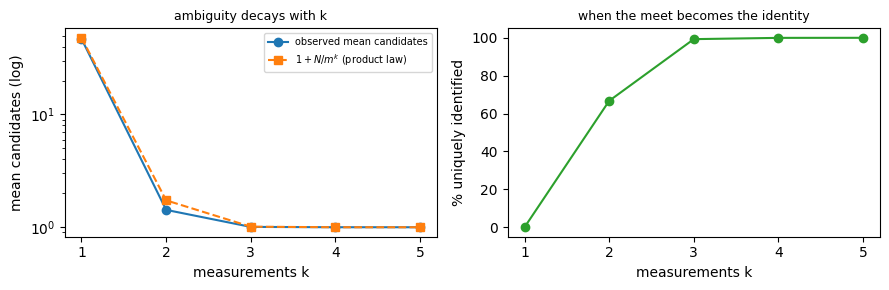

In [6]:

random.seed(2)
NK = 3000
qtoks = [f"q{random.randrange(10 ** 9)}" for _ in range(NK)]
SEEDS = 5
luts = []
for sd in range(SEEDS):
    lut = collections.defaultdict(list)
    for t in qtoks:
        lut[site(t, seed=sd)].append(t)
    luts.append(lut)

print("real plane (m=%d cells), N=%d tokens" % (PLANE_BITS, NK))
print("  k  distinct keys   mean candidates   1+N/m^k   singleton tuples")
for k in range(1, 4):
    groups = collections.defaultdict(list)
    for t in qtoks:
        groups[tuple(site(t, seed=sd) for sd in range(k))].append(t)
    sizes = np.array([len(v) for v in groups.values()])
    print("  %d  %13d   %13.3f   %7.3f   %6.1f%%"
          % (k, len(groups), sizes.mean(), 1 + NK / PLANE_BITS ** k,
             100 * (sizes == 1).mean()))

q = qtoks[0]
cand = set(qtoks)
for sd in range(SEEDS):
    cand &= set(luts[sd][site(q, seed=sd)])
law("materialization = intersection of fibres; no false negatives", q in cand)
print("  materialize %s: |candidates|=%d (query present: %s)" % (q, len(cand), q in cand))

m = 64
CM = 5
coarse = lambda t, sd: (site(t, seed=sd) // BITS_PER_REG) % m
print("coarse measurements (m=%d cells), N=%d tokens" % (m, NK))
means, singles = [], []
for k in range(1, CM + 1):
    groups = collections.defaultdict(list)
    for t in qtoks:
        groups[tuple(coarse(t, sd) for sd in range(k))].append(t)
    sizes = np.array([len(v) for v in groups.values()])
    means.append(sizes.mean())
    singles.append((sizes == 1).mean())
    print("  k=%d  mean candidates %7.2f   1+N/m^k %7.2f   singleton %6.1f%%"
          % (k, sizes.mean(), 1 + NK / m ** k, 100 * (sizes == 1).mean()))
law("triangulation: ambiguity falls with k", means[-1] < means[0])
law("triangulation: unique identification is monotone in k", singles[-1] >= singles[0])

alpha = [f"n{i}" for i in range(16)]
by_cell = collections.defaultdict(list)
for t in alpha:
    by_cell[site(t) % 2].append(t)
a, b = next(v for v in by_cell.values() if len(v) > 1)[:2]
seq = ["m0", a, "m1", b, "m2"]                       # a and b in different contexts
occ = list(range(len(seq)))
sig = lambda i: (seq[i - 1] if i > 0 else None, seq[i + 1] if i < len(seq) - 1 else None)
cell = lambda i: site(seq[i]) % 2                    # the coarse hash cell
same_cell = [i for i in occ if cell(i) == cell(1)]
refined = [i for i in same_cell if sig(i) == sig(1)]
print("  tokens %s and %s share hash cell %d; the n-gram context separates them"
      % (a, b, cell(1)))
law("hash alone cannot separate the two tokens", len({seq[i] for i in same_cell}) > 1)
law("the n-gram context refines the hash cell to one occurrence",
    {seq[i] for i in refined} == {a})

fig, ax = plt.subplots(1, 2, figsize=(9.0, 3.0))
ks = np.arange(1, CM + 1)
ax[0].semilogy(ks, means, "o-", label="observed mean candidates")
ax[0].semilogy(ks, [1 + NK / m ** k for k in ks], "s--", label=r"$1+N/m^k$ (product law)")
ax[0].set_xlabel("measurements k")
ax[0].set_ylabel("mean candidates (log)")
ax[0].set_xticks(ks)
ax[0].legend(fontsize=7)
ax[0].set_title("ambiguity decays with k", fontsize=9)
ax[1].plot(ks, [100 * s for s in singles], "o-", color="tab:green")
ax[1].set_xlabel("measurements k")
ax[1].set_ylabel("% uniquely identified")
ax[1].set_xticks(ks)
ax[1].set_ylim(-5, 105)
ax[1].set_title("when the meet becomes the identity", fontsize=9)
plt.tight_layout()
plt.show()


## §6 — Summary and cross-check

Every claim of `docs/FOL_HLLSET.md` that this notebook exercises:

- **§3** the lattice *is* a Boolean algebra: laws, canonical content id,
  `⊨` as `⊆`, modus ponens — all as bitmap comparisons;
- **§5** `∃`/`∀` are fibre projections: extensive/contractive, idempotent,
  distributive, De Morgan, Galois, commuting; a fully quantified formula is a
  union of join-classes, and it is `∅`/`U` exactly when the coordinates separate
  the universe;
- **§4** local universes: `[∅,L]` Boolean, restriction a homomorphism, retract,
  gluing, world-relative validity and BSS;
- **§3.4** forgetfulness is the kernel: a real collision gives
  `μ(A∩B) ≠ μ(A)∩μ(B)`, and multiplicity is invisible;
- **§3.5** triangulation: the meet of partitions, `1+N/m^k` decay, fibre
  intersection materialization with no false negatives, n-gram refinement.

The mirror's `μ` is the soldered flat map (`P=10`, `M=1024`, `B=32`); the
production `n`-gram morphism is only inclusion-isotonic, so the *union*
identities it satisfies are inclusions, not equalities — see `docs/BOOLRING.md`.

In [7]:

passed = sum(1 for _, ok in CHECKS if ok)
print("checks: %d/%d passed" % (passed, len(CHECKS)))
assert all(ok for _, ok in CHECKS), "a law failed"

contracts = ROOT / "crates" / "hllset-contracts" / "src"
src = "\n".join(p.read_text() for p in contracts.rglob("*.rs")) if contracts.exists() else ""
if "BITS_PER_REG" in src:
    print("cross-check hllset-contracts: PASS (soldered constants present in source)")
else:
    print("cross-check hllset-contracts: SKIP (source not found)")
print("mirror constants asserted locally: P=%d M=%d BITS_PER_REG=%d TOTAL=%d"
      % (P, M, BITS_PER_REG, PLANE_BITS))

checks: 42/42 passed
cross-check hllset-contracts: PASS (soldered constants present in source)
mirror constants asserted locally: P=10 M=1024 BITS_PER_REG=32 TOTAL=32768
